In [32]:
import torch
import torch.nn as nn

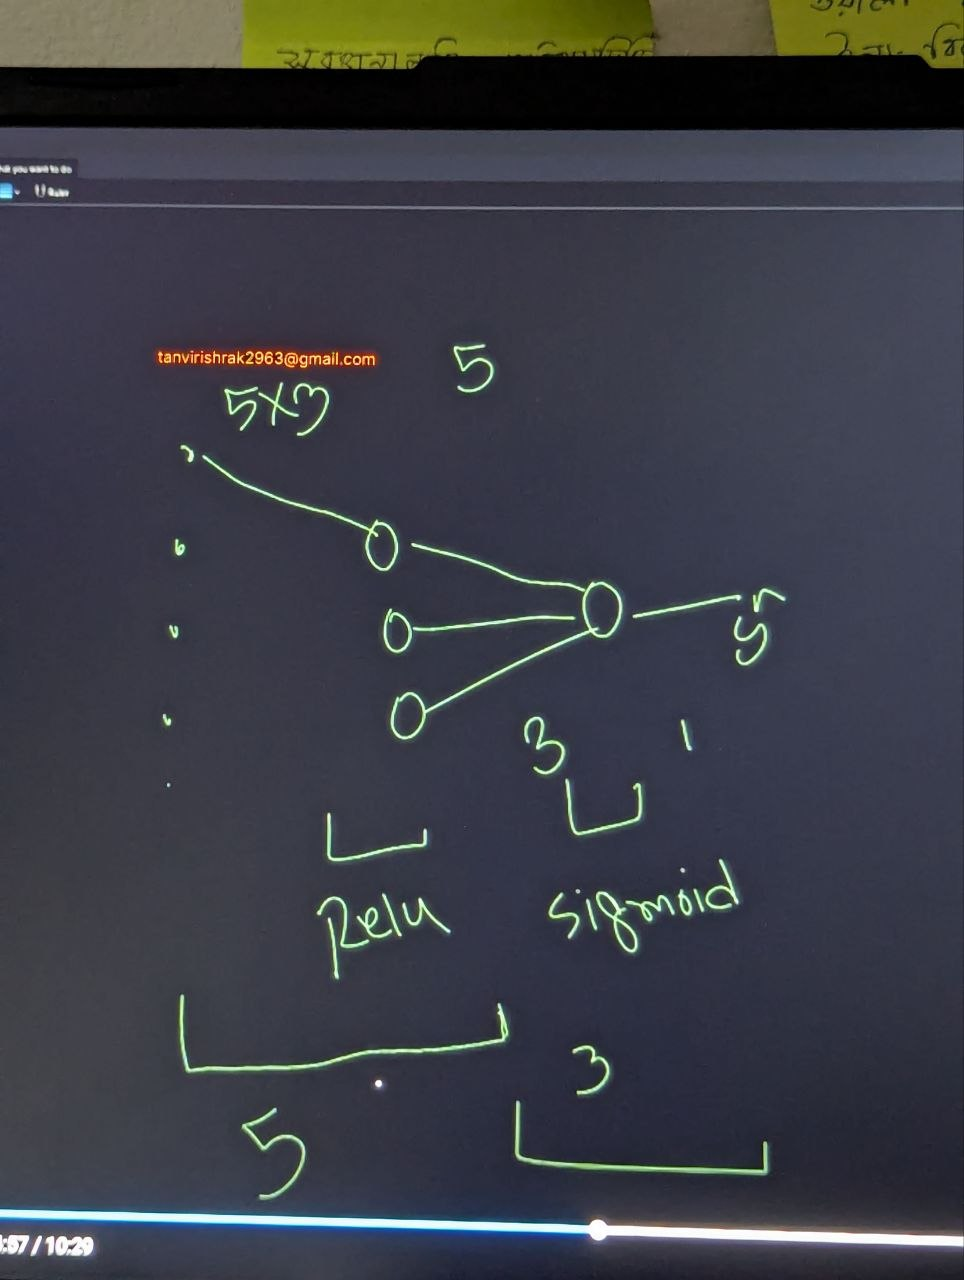

#### version 1 for single layer NN

In [33]:
# class Model(nn.Module):
#   def __init__(self,num_features):
#     super().__init__()

#     self.linear = nn.Linear(num_features,1)
#     self.sigmoid = nn.Sigmoid()


#   def forward(self,features):
#     out = self.linear(features)
#     out = self.sigmoid(out)

#     return out

#### version 2 double layer NN

In [34]:
# class Model(nn.Module):  #nn.Module is inherited
#     def __init__(self, num_features):
#         super().__init__()
        
#         #first layer input
#         self.linear1 = nn.Linear(num_features,3) #(input , output of neural network)
#         #ReLu at first layer
#         self.relu = nn.ReLU() 
        
#         # at second layer
#         self.linear2 = nn.Linear(3,1) #(input , output of neural network)
#         self.sigmoid = nn.Sigmoid()
        
        
#     def forward(self, features):
#         out = self.linear1(features)
#         out = self.relu(out)
        
#         out = self.linear2(out)
#         out = self.sigmoid(out)
            
#         return out

#### version 3 for multiple layers 

In [40]:
class Model(nn.Module):  #nn.Module is inherited
    def __init__(self, num_features):
        super().__init__()
        
        self.network = nn.Sequential(
            #first layer input
            nn.Linear(num_features,3), #(input , output of neural network)
            nn.ReLU(), 
            # at second layer
            nn.Linear(3,1), #(input , output of neural network)
            nn.Sigmoid()
        )
        
        
        
    def forward(self, features):
        out = self.network(features)
            
        return out

In [41]:
# creating model
features = torch.rand(10,5)
features

tensor([[0.9141, 0.4221, 0.1995, 0.5139, 0.9292],
        [0.5314, 0.2883, 0.7241, 0.1796, 0.9357],
        [0.2627, 0.5222, 0.2165, 0.2360, 0.5541],
        [0.6150, 0.7914, 0.9054, 0.6490, 0.7076],
        [0.2488, 0.6581, 0.0621, 0.5717, 0.3379],
        [0.2355, 0.0275, 0.7544, 0.0366, 0.1530],
        [0.5115, 0.8545, 0.8470, 0.8922, 0.6682],
        [0.6041, 0.3347, 0.9129, 0.6546, 0.8234],
        [0.4670, 0.2762, 0.1793, 0.0215, 0.2672],
        [0.7938, 0.7274, 0.6048, 0.8460, 0.8101]])

In [42]:
num_features = features.shape[1]

In [43]:
model = Model(num_features)


In [44]:
# calling model for forward pass
# model.forward(features)
model(features)

tensor([[0.3478],
        [0.3339],
        [0.3831],
        [0.3590],
        [0.3957],
        [0.3091],
        [0.3717],
        [0.3325],
        [0.3461],
        [0.3566]], grad_fn=<SigmoidBackward0>)

In [49]:
#show model weights
model.network[0].weight

Parameter containing:
tensor([[ 0.4140, -0.3025,  0.0835,  0.1369,  0.3928],
        [ 0.1340, -0.3238,  0.3788, -0.2890, -0.4371],
        [ 0.2193,  0.0665, -0.4362,  0.0417, -0.1035]], requires_grad=True)

In [50]:
# visualize
from torchinfo import summary
summary(model, input_size=(10,5))


Layer (type:depth-idx)                   Output Shape              Param #
Model                                    [10, 1]                   --
├─Sequential: 1-1                        [10, 1]                   --
│    └─Linear: 2-1                       [10, 3]                   18
│    └─ReLU: 2-2                         [10, 3]                   --
│    └─Linear: 2-3                       [10, 1]                   4
│    └─Sigmoid: 2-4                      [10, 1]                   --
Total params: 22
Trainable params: 22
Non-trainable params: 0
Total mult-adds (M): 0.00
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00